# FINAL PROJECT - BIG DATA DAN DATA MINING
## Analisis dan Prediksi Data dengan Pendekatan Big Data Mining

---

**Metode yang digunakan:**
1. **Klasifikasi** (Random Forest, Decision Tree, KNN) - Prediksi High Value Customer
2. **Clustering** (K-Means, Hierarchical) - Segmentasi Customer RFM
3. **Association Rule Mining** (Apriori) - Market Basket Analysis

**Dataset Publik:**
- **Groceries Dataset** - Data transaksi supermarket dari URL publik
- **Sumber**: https://github.com/stedy/Machine-Learning-with-R-datasets
- 1 Dataset untuk semua metode analisis

---

## BAGIAN 1: IMPORT LIBRARY

In [13]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [5]:
# ============================================================================
# BAGIAN 1: IMPORT LIBRARY
# ============================================================================

# Install pygwalker jika belum terinstall
try:
    import pygwalker as pyg
except ModuleNotFoundError:
    !pip install pygwalker -q
    import pygwalker as pyg

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import ssl
import urllib.request
warnings.filterwarnings('ignore')

# Fix SSL certificate issue untuk macOS
ssl._create_default_https_context = ssl._create_unverified_context

# Library untuk Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, silhouette_score)

# Library untuk Klasifikasi
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Library untuk Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering

# Library untuk Association Rule Mining
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

print("="*70)
print("FINAL PROJECT - BIG DATA DAN DATA MINING")
print("="*70)
print("\nSemua library berhasil diimport!")
print("PyGWalker tersedia untuk visualisasi interaktif!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 42.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.2/956.2 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 116.1 MB/s eta 0:00:0000:01
FINAL PROJECT - BIG DATA DAN DATA MINING

Semua library berhasil diimport!
PyGWalker tersedia untuk visualisasi interaktif!


---
## BAGIAN 2: LOAD DATASET PUBLIK

### Dataset: Groceries Dataset
- **Sumber**: https://github.com/stedy/Machine-Learning-with-R-datasets
- **Deskripsi**: Data transaksi belanja supermarket dengan 9,835 transaksi
- **Produk**: 169 produk unik (whole milk, vegetables, yogurt, dll)

**Penggunaan Dataset untuk 3 Metode:**
1. **Association Rules**: Langsung menggunakan data transaksi
2. **RFM Analysis**: Dikonversi dengan CustomerID untuk Klasifikasi & Clustering
3. **Klasifikasi**: Prediksi High Value Customer berdasarkan RFM

In [6]:
# ============================================================================
# BAGIAN 2: LOAD DATASET PUBLIK - GROCERIES (untuk semua metode)
# ============================================================================
print("\n" + "="*70)
print("BAGIAN 2: LOAD DATASET PUBLIK")
print("="*70)

print("\n[2.1] Loading Groceries Dataset dari URL...")
print("-"*50)

# URL Dataset Groceries dari Machine Learning with R
# Sumber: https://github.com/stedy/Machine-Learning-with-R-datasets
URL_GROCERIES = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv"

print(f"Sumber: {URL_GROCERIES}")

# Load transaksi dari URL
transactions_raw = []
with urllib.request.urlopen(URL_GROCERIES) as response:
    content = response.read().decode('utf-8')
    for line in content.strip().split('\n'):
        items = [item.strip() for item in line.split(',') if item.strip()]
        if items:
            transactions_raw.append(items)

print(f"Dataset berhasil dimuat!")
print(f"Jumlah transaksi: {len(transactions_raw)}")

# Hitung produk unik
all_items = set()
for trans in transactions_raw:
    all_items.update(trans)
print(f"Jumlah produk unik: {len(all_items)}")

# Konversi ke DataFrame untuk analisis RFM (Klasifikasi & Clustering)
print("\n[2.2] Konversi ke DataFrame untuk RFM Analysis...")
print("-"*50)

np.random.seed(42)
records = []

for i, trans in enumerate(transactions_raw):
    invoice_no = 100000 + i
    # Assign customer dengan pola: beberapa customer beli berkali-kali
    customer_id = np.random.choice(range(10000, 13000), p=None)
    date = pd.Timestamp('2023-01-01') + pd.Timedelta(days=np.random.randint(0, 365))
    
    for item in trans:
        records.append({
            'InvoiceNo': str(invoice_no),
            'StockCode': f'SKU{abs(hash(item)) % 10000:04d}',
            'Description': item,
            'Quantity': np.random.randint(1, 10),
            'InvoiceDate': date,
            'UnitPrice': round(np.random.uniform(0.5, 15.0), 2),
            'CustomerID': float(customer_id),
            'Country': np.random.choice(['United Kingdom', 'France', 'Germany', 'Spain'], 
                                        p=[0.85, 0.07, 0.05, 0.03])
        })

df_retail = pd.DataFrame(records)

# Calculate TotalPrice
df_retail['TotalPrice'] = df_retail['Quantity'] * df_retail['UnitPrice']

print(f"\n[2.3] Statistik Dataset")
print("-"*50)
print(f"Jumlah record transaksi: {len(df_retail):,}")
print(f"Jumlah invoice unik: {df_retail['InvoiceNo'].nunique():,}")
print(f"Jumlah customer unik: {int(df_retail['CustomerID'].nunique()):,}")
print(f"Jumlah produk unik: {df_retail['Description'].nunique()}")
print(f"Periode: {df_retail['InvoiceDate'].min().strftime('%Y-%m-%d')} s/d {df_retail['InvoiceDate'].max().strftime('%Y-%m-%d')}")

# Simpan transaksi asli untuk Association Rules
transactions = transactions_raw.copy()
print(f"\nTransaksi untuk Association Rules: {len(transactions)} transaksi")


BAGIAN 2: LOAD DATASET PUBLIK

[2.1] Loading Groceries Dataset dari URL...
--------------------------------------------------
Sumber: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv
Dataset berhasil dimuat!
Jumlah transaksi: 9835
Jumlah produk unik: 169

[2.2] Konversi ke DataFrame untuk RFM Analysis...
--------------------------------------------------

[2.3] Statistik Dataset
--------------------------------------------------
Jumlah record transaksi: 43,367
Jumlah invoice unik: 9,835
Jumlah customer unik: 2,903
Jumlah produk unik: 169
Periode: 2023-01-01 s/d 2023-12-31

Transaksi untuk Association Rules: 9835 transaksi


In [7]:
# 2.2 Preview Dataset
print("\n[2.2] Preview Dataset Online Retail")
print("-"*50)
print(f"\nKolom dataset: {list(df_retail.columns)}")
df_retail.head(10)


[2.2] Preview Dataset Online Retail
--------------------------------------------------

Kolom dataset: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,100000,SKU5512,citrus fruit,8,2023-09-28,9.18,10860.0,United Kingdom,73.44
1,100000,SKU6948,semi-finished bread,3,2023-09-28,1.95,10860.0,United Kingdom,5.85
2,100000,SKU1656,margarine,5,2023-09-28,9.22,10860.0,United Kingdom,46.10
3,100000,SKU5143,ready soups,6,2023-09-28,1.32,10860.0,United Kingdom,7.92
4,100001,SKU2622,tropical fruit,5,2023-07-11,9.45,12853.0,United Kingdom,47.25
5,100001,SKU7031,yogurt,9,2023-07-11,4.72,12853.0,United Kingdom,42.48
6,100001,SKU1266,coffee,3,2023-07-11,6.05,12853.0,Spain,18.15
7,100002,SKU8775,whole milk,5,2023-05-11,9.31,11528.0,United Kingdom,46.55
8,100003,SKU7903,pip fruit,4,2023-10-01,14.16,12214.0,United Kingdom,56.64
9,100003,SKU7031,yogurt,9,2023-10-01,0.73,12214.0,United Kingdom,6.57


In [8]:
# 2.3 Statistik Dataset
print("\n[2.3] Statistik Dataset")
print("-"*50)
print(df_retail.describe())


[2.3] Statistik Dataset
--------------------------------------------------
           Quantity                    InvoiceDate     UnitPrice  \
count  43367.000000                          43367  43367.000000   
mean       4.990961  2023-06-30 08:50:15.011414272      7.756945   
min        1.000000            2023-01-01 00:00:00      0.500000   
25%        3.000000            2023-04-01 00:00:00      4.170000   
50%        5.000000            2023-07-01 00:00:00      7.750000   
75%        7.000000            2023-09-28 00:00:00     11.380000   
max        9.000000            2023-12-31 00:00:00     15.000000   
std        2.583925                            NaN      4.177158   

         CustomerID    TotalPrice  
count  43367.000000  43367.000000  
mean   11504.580718     38.625533  
min    10000.000000      0.500000  
25%    10757.500000     13.210000  
50%    11497.000000     29.820000  
75%    12258.000000     57.240000  
max    12999.000000    135.000000  
std      864.139433    

### 📊 Visualisasi Interaktif dengan PyGWalker
PyGWalker adalah library yang memungkinkan eksplorasi data secara interaktif seperti Tableau. Anda dapat:
- Drag & drop kolom untuk membuat visualisasi
- Memilih berbagai jenis chart (bar, line, scatter, dll)
- Filter dan group data secara dinamis

In [9]:
# 2.4 Visualisasi Interaktif dengan PyGWalker
print("\n[2.4] PyGWalker - Eksplorasi Data Interaktif")
print("-"*50)
print("Gunakan interface di bawah untuk membuat visualisasi interaktif!")
print("Tips: Drag kolom ke X/Y axis, pilih chart type, dan explore data Anda\n")

# Membuat visualisasi interaktif dengan PyGWalker
walker = pyg.walk(df_retail, return_html=True)


[2.4] PyGWalker - Eksplorasi Data Interaktif
--------------------------------------------------
Gunakan interface di bawah untuk membuat visualisasi interaktif!
Tips: Drag kolom ke X/Y axis, pilih chart type, dan explore data Anda



Box(children=(HTML(value='\n<div id="ifr-pyg-000648d0b426c783ZV3LigJIlRhyHxcS" style="height: auto">\n    <hea…

In [10]:
# 2.4 Preview Transaksi untuk Association Rules
print("\n[2.4] Preview Data Transaksi (dari Groceries Dataset)")
print("-"*50)

# Gunakan transaksi asli dari URL (sudah tersimpan di transactions_raw)
print(f"Jumlah transaksi total: {len(transactions_raw)}")

# Filter transaksi yang memiliki lebih dari 1 item
transactions_filtered = [t for t in transactions_raw if len(t) > 1]
print(f"Jumlah transaksi dengan >1 item: {len(transactions_filtered)}")

print(f"\n5 Transaksi pertama:")
for i, trans in enumerate(transactions_filtered[:5], 1):
    print(f"  Transaksi {i}: {trans}")


[2.4] Preview Data Transaksi (dari Groceries Dataset)
--------------------------------------------------
Jumlah transaksi total: 9835
Jumlah transaksi dengan >1 item: 7676

5 Transaksi pertama:
  Transaksi 1: ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']
  Transaksi 2: ['tropical fruit', 'yogurt', 'coffee']
  Transaksi 3: ['pip fruit', 'yogurt', 'cream cheese', 'meat spreads']
  Transaksi 4: ['other vegetables', 'whole milk', 'condensed milk', 'long life bakery product']
  Transaksi 5: ['whole milk', 'butter', 'yogurt', 'rice', 'abrasive cleaner']


---
## BAGIAN 3: EXPLORATORY DATA ANALYSIS (EDA)

In [11]:
# ============================================================================
# BAGIAN 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================
print("\n" + "="*70)
print("BAGIAN 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*70)

# 3.1 Info Dataset
print("\n[3.1] Informasi Dataset Online Retail")
print("-"*50)
df_retail.info()


BAGIAN 3: EXPLORATORY DATA ANALYSIS (EDA)

[3.1] Informasi Dataset Online Retail
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43367 entries, 0 to 43366
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    43367 non-null  object        
 1   StockCode    43367 non-null  object        
 2   Description  43367 non-null  object        
 3   Quantity     43367 non-null  int64         
 4   InvoiceDate  43367 non-null  datetime64[ns]
 5   UnitPrice    43367 non-null  float64       
 6   CustomerID   43367 non-null  float64       
 7   Country      43367 non-null  object        
 8   TotalPrice   43367 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 3.0+ MB


In [12]:
# 3.2 Missing Values
print("\n[3.2] Pengecekan Missing Values")
print("-"*50)

missing = df_retail.isnull().sum()
if missing.sum() > 0:
    print("Kolom dengan missing values:")
    print(missing[missing > 0])
else:
    print("Tidak ada missing values!")


[3.2] Pengecekan Missing Values
--------------------------------------------------
Tidak ada missing values!



[3.3] Top 10 Produk Terlaris
--------------------------------------------------
Description
RECIPE BOX WITH METAL HEART           4068
DOORMAT NEW ENGLAND                   4063
IVORY KNITTED MUG COSY                3838
FELTCRAFT PRINCESS CHARLOTTE DOLL     3812
WHITE HANGING HEART T-LIGHT HOLDER    3787
WHITE METAL LANTERN                   3730
SET 7 BABUSHKA NESTING BOXES          3725
POPPY FLOWER COAT HANGER              3717
BOX OF 6 ASSORTED COLOUR TEASPOONS    3714
CREAM CUPID HEARTS COAT HANGER        3697
Name: Quantity, dtype: int64


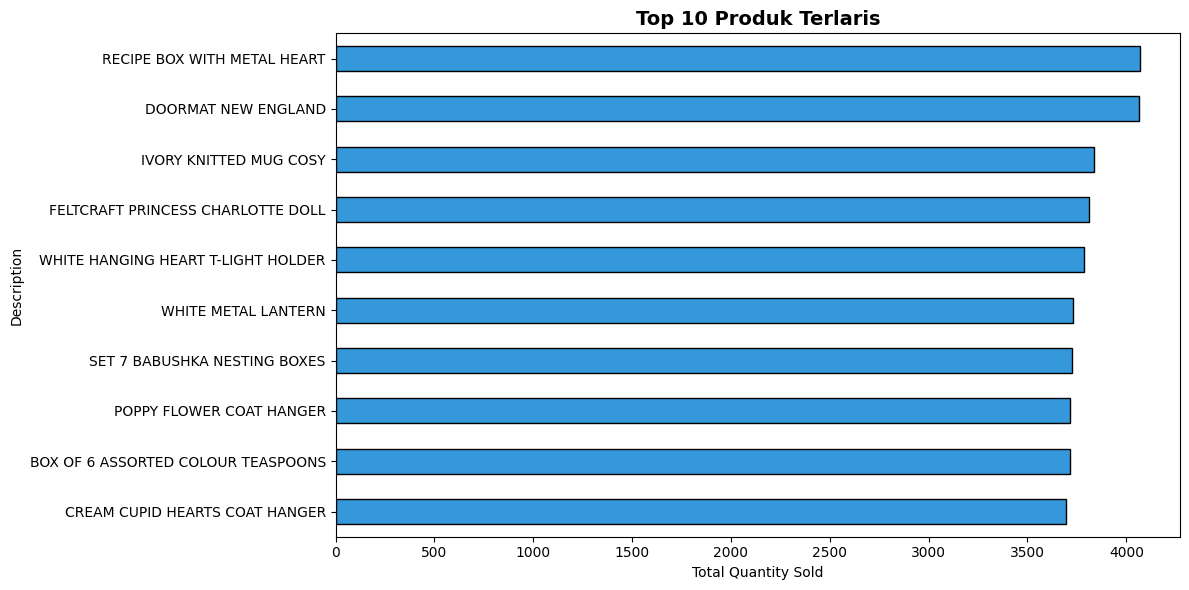

In [8]:
# 3.3 Top Products
print("\n[3.3] Top 10 Produk Terlaris")
print("-"*50)

top_products = df_retail.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 6))
top_products.plot(kind='barh', color='#3498db', edgecolor='black', ax=ax)
ax.set_title('Top 10 Produk Terlaris', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Quantity Sold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


[3.4] Distribusi Customer per Negara
--------------------------------------------------
Country
United Kingdom    1424
France             233
Germany            204
Spain              149
Netherlands         98
Belgium             45
Name: CustomerID, dtype: int64


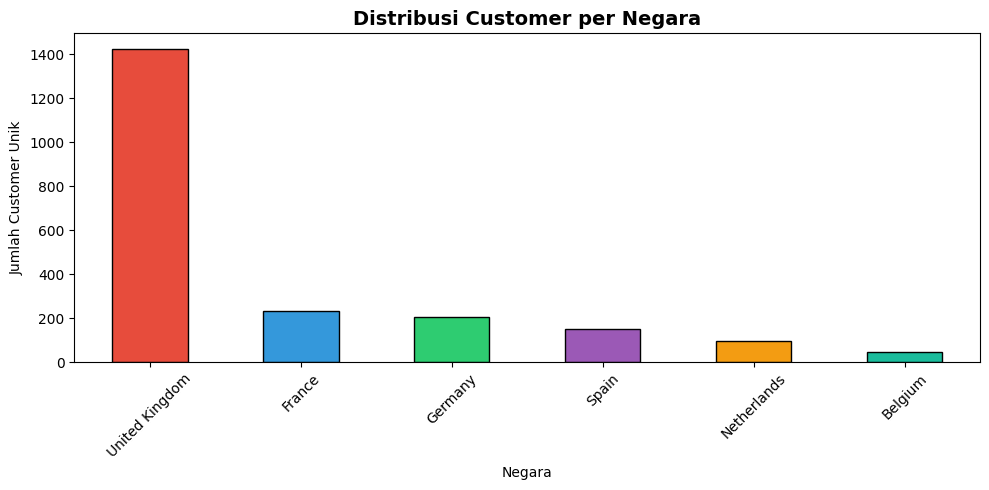

In [9]:
# 3.4 Distribusi Customer per Negara
print("\n[3.4] Distribusi Customer per Negara")
print("-"*50)

country_dist = df_retail.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)
print(country_dist)

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']
country_dist.plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Distribusi Customer per Negara', fontsize=14, fontweight='bold')
ax.set_ylabel('Jumlah Customer Unik')
ax.set_xlabel('Negara')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


[3.5] Distribusi Penjualan per Bulan
--------------------------------------------------


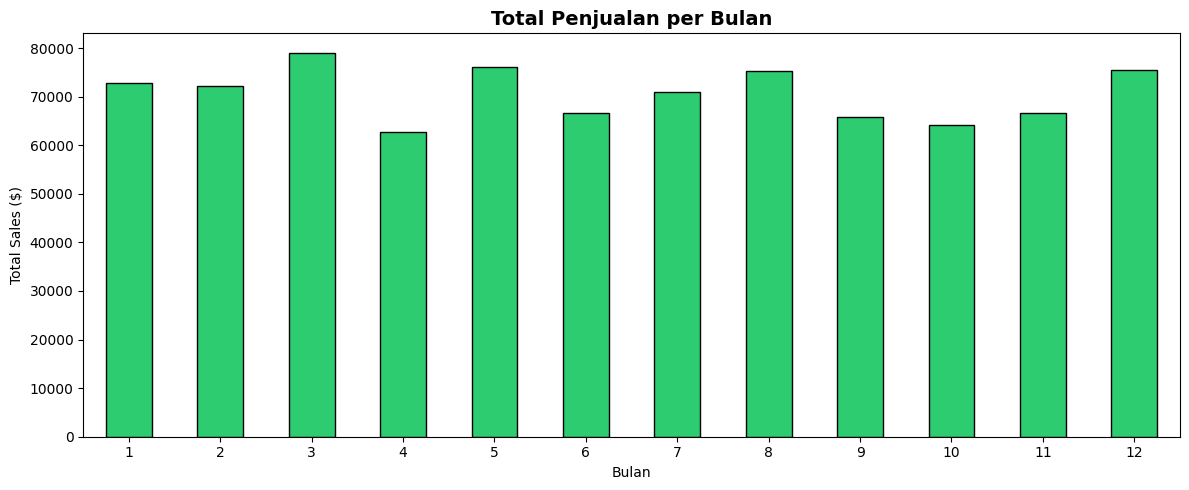

In [10]:
# 3.5 Distribusi Penjualan per Bulan
print("\n[3.5] Distribusi Penjualan per Bulan")
print("-"*50)

df_retail['Month'] = df_retail['InvoiceDate'].dt.month
monthly_sales = df_retail.groupby('Month')['TotalPrice'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
monthly_sales.plot(kind='bar', color='#2ecc71', edgecolor='black', ax=ax)
ax.set_title('Total Penjualan per Bulan', fontsize=14, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## BAGIAN 4: DATA PREPROCESSING - RFM ANALYSIS

RFM (Recency, Frequency, Monetary) Analysis untuk:
- **Klasifikasi**: Prediksi High Value Customer
- **Clustering**: Segmentasi Customer

In [11]:
# ============================================================================
# BAGIAN 4: DATA PREPROCESSING - RFM ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("BAGIAN 4: DATA PREPROCESSING - RFM ANALYSIS")
print("="*70)

print("\n[4.1] Membuat RFM Features untuk setiap Customer")
print("-"*50)

# Reference date (hari terakhir + 1)
reference_date = df_retail['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM
rfm = df_retail.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'TotalPrice': 'sum'  # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Tambah fitur tambahan
customer_stats = df_retail.groupby('CustomerID').agg({
    'Quantity': 'sum',
    'Description': 'nunique',  # Jumlah produk unik yang dibeli
    'Country': 'first'
}).reset_index()
customer_stats.columns = ['CustomerID', 'TotalQuantity', 'UniqueProducts', 'Country']

# Merge
rfm = rfm.merge(customer_stats, on='CustomerID')

print(f"Jumlah customer: {len(rfm)}")
print(f"\nStatistik RFM:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())


BAGIAN 4: DATA PREPROCESSING - RFM ANALYSIS

[4.1] Membuat RFM Features untuk setiap Customer
--------------------------------------------------
Jumlah customer: 1457

Statistik RFM:
           Recency    Frequency     Monetary
count  1457.000000  1457.000000  1457.000000
mean     99.507207     3.431709   582.078545
std      85.610663     1.688572   343.714898
min       1.000000     1.000000     6.420000
25%      30.000000     2.000000   325.280000
50%      74.000000     3.000000   530.200000
75%     148.000000     4.000000   796.110000
max     364.000000    10.000000  2089.580000


In [12]:
# 4.2 Preview RFM Data
print("\n[4.2] Preview RFM Data")
print("-"*50)
rfm.head(10)


[4.2] Preview RFM Data
--------------------------------------------------


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,Country
0,10000,247,1,68.90,9,2,United Kingdom
1,10001,164,2,237.48,22,4,United Kingdom
2,10002,79,3,390.82,33,6,United Kingdom
3,10003,73,4,857.27,58,7,Netherlands
4,10004,283,1,258.80,17,2,United Kingdom
5,10005,9,2,302.36,40,5,United Kingdom
6,10006,10,5,955.07,62,9,United Kingdom
7,10007,72,5,860.85,60,8,United Kingdom
8,10008,59,3,424.32,36,5,Spain
9,10009,16,5,760.62,45,7,United Kingdom


In [13]:
# 4.3 Create Target Variable untuk Klasifikasi
print("\n[4.3] Membuat Target Variable untuk Klasifikasi")
print("-"*50)

# Target: High Value Customer (Monetary > median DAN Frequency > median)
median_monetary = rfm['Monetary'].median()
median_frequency = rfm['Frequency'].median()

rfm['HighValue'] = ((rfm['Monetary'] > median_monetary) & 
                     (rfm['Frequency'] > median_frequency)).astype(int)

print(f"Threshold Monetary: > ${median_monetary:.2f}")
print(f"Threshold Frequency: > {median_frequency:.0f} transaksi")
print(f"\nDistribusi Target:")
print(f"  Regular Customer (0): {(rfm['HighValue']==0).sum()} ({(rfm['HighValue']==0).mean()*100:.1f}%)")
print(f"  High Value (1)      : {(rfm['HighValue']==1).sum()} ({(rfm['HighValue']==1).mean()*100:.1f}%)")


[4.3] Membuat Target Variable untuk Klasifikasi
--------------------------------------------------
Threshold Monetary: > $530.20
Threshold Frequency: > 3 transaksi

Distribusi Target:
  Regular Customer (0): 906 (62.2%)
  High Value (1)      : 551 (37.8%)



[4.4] Visualisasi Distribusi Target
--------------------------------------------------


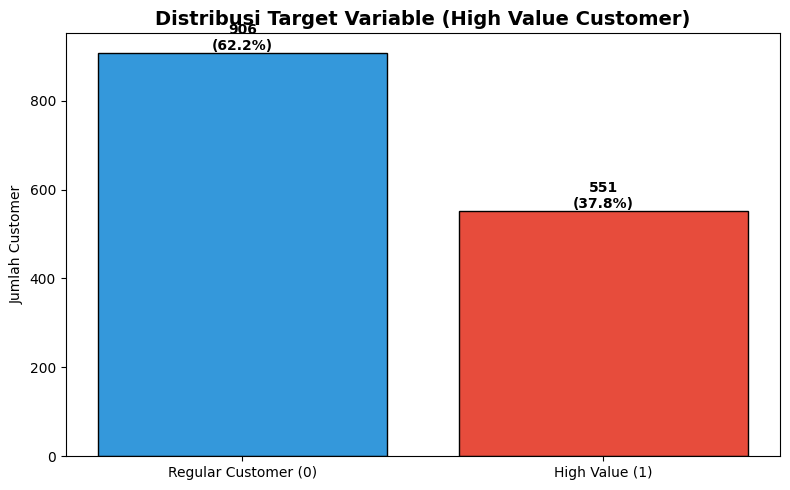

In [14]:
# 4.4 Visualisasi Distribusi Target
print("\n[4.4] Visualisasi Distribusi Target")
print("-"*50)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db', '#e74c3c']
target_counts = rfm['HighValue'].value_counts().sort_index()
bars = ax.bar(['Regular Customer (0)', 'High Value (1)'], target_counts.values, color=colors, edgecolor='black')
ax.set_title('Distribusi Target Variable (High Value Customer)', fontsize=14, fontweight='bold')
ax.set_ylabel('Jumlah Customer')

for bar, count in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{count}\n({count/len(rfm)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# 4.5 Persiapan Fitur untuk Klasifikasi
print("\n[4.5] Persiapan Fitur untuk Klasifikasi")
print("-"*50)

# Features untuk klasifikasi
feature_cols = ['Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'UniqueProducts']
X = rfm[feature_cols].copy()
y = rfm['HighValue']

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Fitur yang digunakan: {feature_cols}")
print(f"Data Training: {len(X_train)} sampel (80%)")
print(f"Data Testing : {len(X_test)} sampel (20%)")


[4.5] Persiapan Fitur untuk Klasifikasi
--------------------------------------------------
Fitur yang digunakan: ['Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'UniqueProducts']
Data Training: 1165 sampel (80%)
Data Testing : 292 sampel (20%)


---
## BAGIAN 5: IMPLEMENTASI KLASIFIKASI

**Target**: Prediksi High Value Customer  
**Dataset**: Online Retail (RFM Features)

Model yang digunakan:
1. Random Forest Classifier
2. Decision Tree Classifier
3. K-Nearest Neighbors (KNN)

In [16]:
# ============================================================================
# BAGIAN 5: IMPLEMENTASI KLASIFIKASI
# ============================================================================
print("\n" + "="*70)
print("BAGIAN 5: IMPLEMENTASI KLASIFIKASI")
print("="*70)

# Dictionary untuk menyimpan hasil
hasil_klasifikasi = {}

# 5.1 Random Forest
print("\n[5.1] Random Forest Classifier")
print("-"*50)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
hasil_klasifikasi['Random Forest'] = rf_acc

print(f"Akurasi: {rf_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Regular', 'High Value']))


BAGIAN 5: IMPLEMENTASI KLASIFIKASI

[5.1] Random Forest Classifier
--------------------------------------------------
Akurasi: 100.00%

Classification Report:
              precision    recall  f1-score   support

     Regular       1.00      1.00      1.00       182
  High Value       1.00      1.00      1.00       110

    accuracy                           1.00       292
   macro avg       1.00      1.00      1.00       292
weighted avg       1.00      1.00      1.00       292



In [17]:
# 5.2 Decision Tree
print("\n[5.2] Decision Tree Classifier")
print("-"*50)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
hasil_klasifikasi['Decision Tree'] = dt_acc

print(f"Akurasi: {dt_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=['Regular', 'High Value']))


[5.2] Decision Tree Classifier
--------------------------------------------------
Akurasi: 100.00%

Classification Report:
              precision    recall  f1-score   support

     Regular       1.00      1.00      1.00       182
  High Value       1.00      1.00      1.00       110

    accuracy                           1.00       292
   macro avg       1.00      1.00      1.00       292
weighted avg       1.00      1.00      1.00       292



In [18]:
# 5.3 K-Nearest Neighbors
print("\n[5.3] K-Nearest Neighbors (KNN)")
print("-"*50)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
hasil_klasifikasi['KNN'] = knn_acc

print(f"Akurasi: {knn_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, knn_pred, target_names=['Regular', 'High Value']))


[5.3] K-Nearest Neighbors (KNN)
--------------------------------------------------
Akurasi: 97.60%

Classification Report:
              precision    recall  f1-score   support

     Regular       0.99      0.97      0.98       182
  High Value       0.96      0.98      0.97       110

    accuracy                           0.98       292
   macro avg       0.97      0.98      0.97       292
weighted avg       0.98      0.98      0.98       292



In [19]:
# 5.4 Cross-Validation
print("\n[5.4] Cross-Validation (5-Fold)")
print("-"*50)

models = {
    'Random Forest': rf_model,
    'Decision Tree': dt_model,
    'KNN': knn_model
}

print(f"{'Model':<20} {'Mean CV':>10} {'Std CV':>10}")
print("-"*42)
for name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled, y, cv=5)
    print(f"{name:<20} {cv_scores.mean()*100:>9.2f}% {cv_scores.std()*100:>9.2f}%")


[5.4] Cross-Validation (5-Fold)
--------------------------------------------------
Model                   Mean CV     Std CV
------------------------------------------
Random Forest            99.86%      0.17%
Decision Tree            99.86%      0.27%
KNN                      97.73%      0.91%


In [20]:
# 5.5 Perbandingan Model
print("\n[5.5] Perbandingan Akurasi Model")
print("-"*50)

print(f"{'Model':<20} {'Akurasi':>10}")
print("-"*32)
for model, acc in sorted(hasil_klasifikasi.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:<20} {acc*100:>9.2f}%")

best_model = max(hasil_klasifikasi, key=hasil_klasifikasi.get)
print(f"\nModel Terbaik: {best_model} ({hasil_klasifikasi[best_model]*100:.2f}%)")


[5.5] Perbandingan Akurasi Model
--------------------------------------------------
Model                   Akurasi
--------------------------------
Random Forest           100.00%
Decision Tree           100.00%
KNN                      97.60%

Model Terbaik: Random Forest (100.00%)



[5.6] Visualisasi Hasil Klasifikasi
--------------------------------------------------


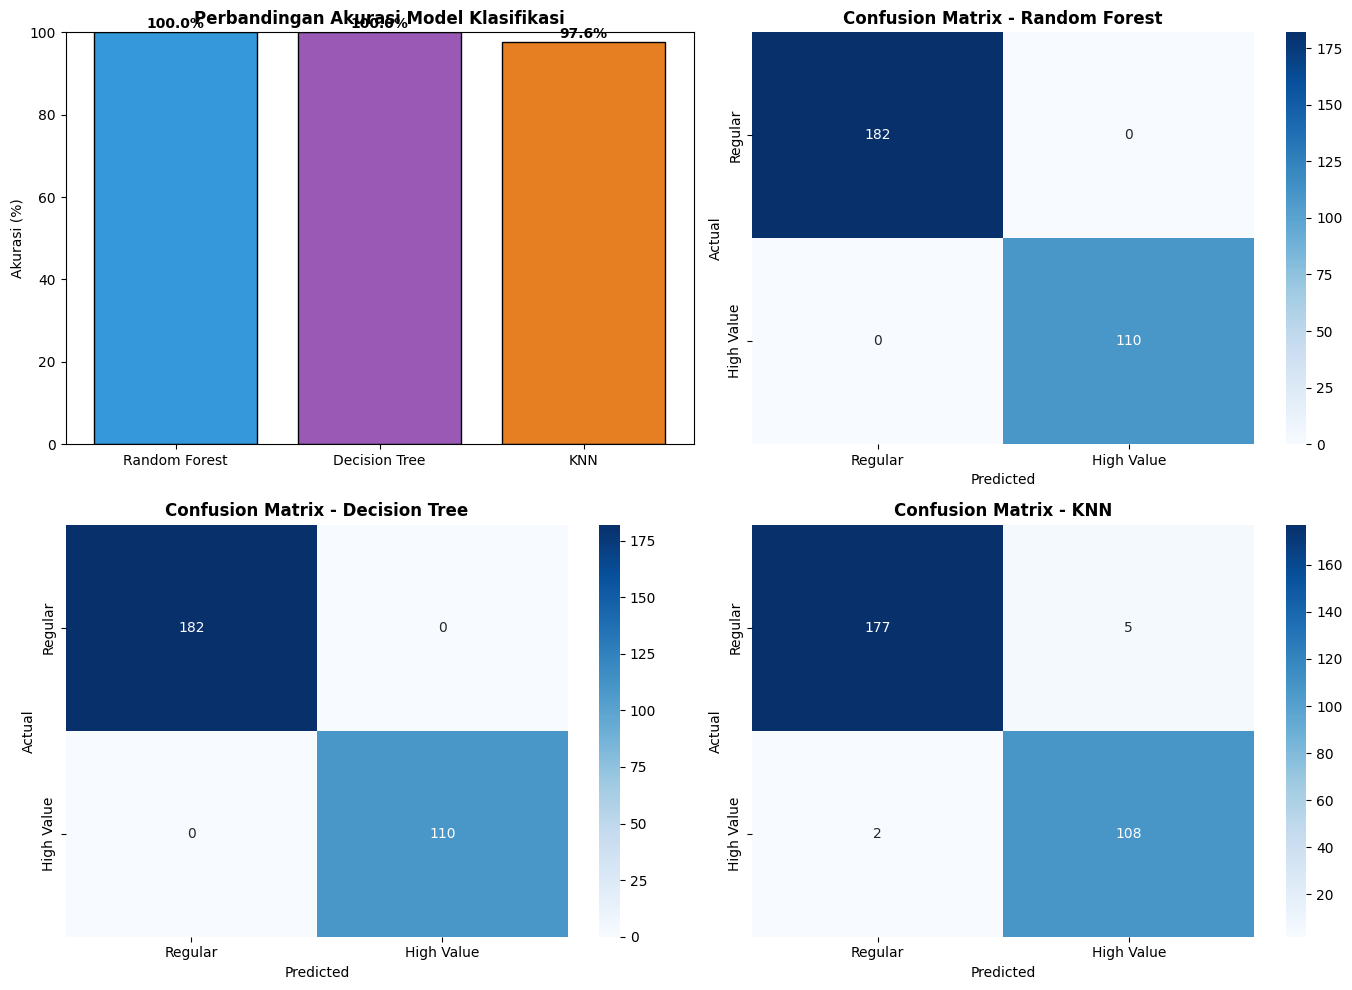

In [21]:
# 5.6 Visualisasi Perbandingan & Confusion Matrix
print("\n[5.6] Visualisasi Hasil Klasifikasi")
print("-"*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Perbandingan Akurasi
ax1 = axes[0, 0]
models_list = list(hasil_klasifikasi.keys())
accs = [v * 100 for v in hasil_klasifikasi.values()]
colors_bar = ['#3498db', '#9b59b6', '#e67e22']
bars = ax1.bar(models_list, accs, color=colors_bar, edgecolor='black')
ax1.set_title('Perbandingan Akurasi Model Klasifikasi', fontsize=12, fontweight='bold')
ax1.set_ylabel('Akurasi (%)')
ax1.set_ylim(0, 100)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.1f}%', ha='center', fontweight='bold')

# Plot 2-4: Confusion Matrix
predictions = [rf_pred, dt_pred, knn_pred]
titles = ['Random Forest', 'Decision Tree', 'KNN']
positions = [(0, 1), (1, 0), (1, 1)]

for pred, title, pos in zip(predictions, titles, positions):
    ax = axes[pos]
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Regular', 'High Value'],
                yticklabels=['Regular', 'High Value'])
    ax.set_title(f'Confusion Matrix - {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


[5.7] Feature Importance (Random Forest)
--------------------------------------------------
Fitur Paling Berpengaruh:
       Feature  Importance
     Frequency    0.430102
      Monetary    0.307673
 TotalQuantity    0.194286
UniqueProducts    0.058097
       Recency    0.009842


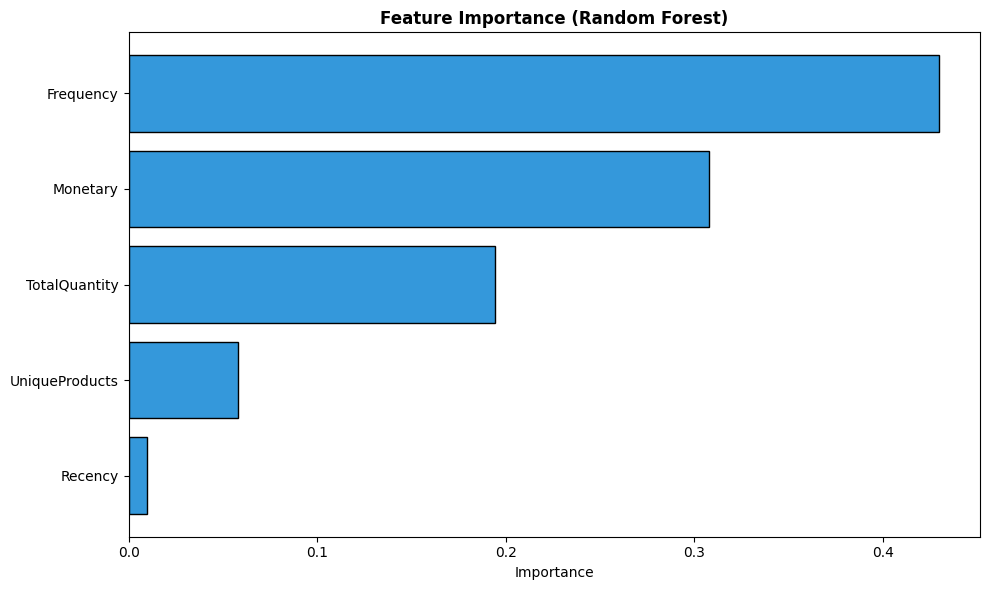

In [22]:
# 5.7 Feature Importance
print("\n[5.7] Feature Importance (Random Forest)")
print("-"*50)

feature_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Fitur Paling Berpengaruh:")
print(feature_imp.to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 6))
top_feat = feature_imp.sort_values('Importance')
ax.barh(top_feat['Feature'], top_feat['Importance'], color='#3498db', edgecolor='black')
ax.set_xlabel('Importance')
ax.set_title('Feature Importance (Random Forest)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## BAGIAN 6: IMPLEMENTASI CLUSTERING

**Dataset**: Online Retail (RFM Features)  
**Fitur**: Recency, Frequency, Monetary

Metode yang digunakan:
1. K-Means Clustering
2. Hierarchical Clustering (Agglomerative)

In [23]:
# ============================================================================
# BAGIAN 6: IMPLEMENTASI CLUSTERING
# ============================================================================
print("\n" + "="*70)
print("BAGIAN 6: IMPLEMENTASI CLUSTERING")
print("="*70)

# 6.1 Persiapan Data
print("\n[6.1] Persiapan Data untuk Clustering")
print("-"*50)

# Gunakan fitur RFM
cluster_features = ['Recency', 'Frequency', 'Monetary']
X_cluster = rfm[cluster_features].copy()

# Normalisasi
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f"Fitur untuk clustering: {cluster_features}")
print(f"Jumlah customer: {len(X_cluster)}")


BAGIAN 6: IMPLEMENTASI CLUSTERING

[6.1] Persiapan Data untuk Clustering
--------------------------------------------------
Fitur untuk clustering: ['Recency', 'Frequency', 'Monetary']
Jumlah customer: 1457


In [24]:
# 6.2 Elbow Method & Silhouette
print("\n[6.2] Menentukan Jumlah Cluster Optimal")
print("-"*50)

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

print(f"{'K':>3} {'Inertia':>12} {'Silhouette':>12}")
print("-"*30)
for k, iner, sil in zip(K_range, inertias, silhouettes):
    print(f"{k:>3} {iner:>12.2f} {sil:>12.4f}")

optimal_k = list(K_range)[np.argmax(silhouettes)]
print(f"\nJumlah cluster optimal (Silhouette tertinggi): K = {optimal_k}")


[6.2] Menentukan Jumlah Cluster Optimal
--------------------------------------------------
  K      Inertia   Silhouette
------------------------------
  2      2369.66       0.3822
  3      1569.94       0.3651
  4      1236.58       0.3292
  5      1043.58       0.3326
  6       894.82       0.3049
  7       788.89       0.2934
  8       719.53       0.2936
  9       659.90       0.2982
 10       608.12       0.2846

Jumlah cluster optimal (Silhouette tertinggi): K = 2



[6.3] Visualisasi Elbow Method & Silhouette Score
--------------------------------------------------


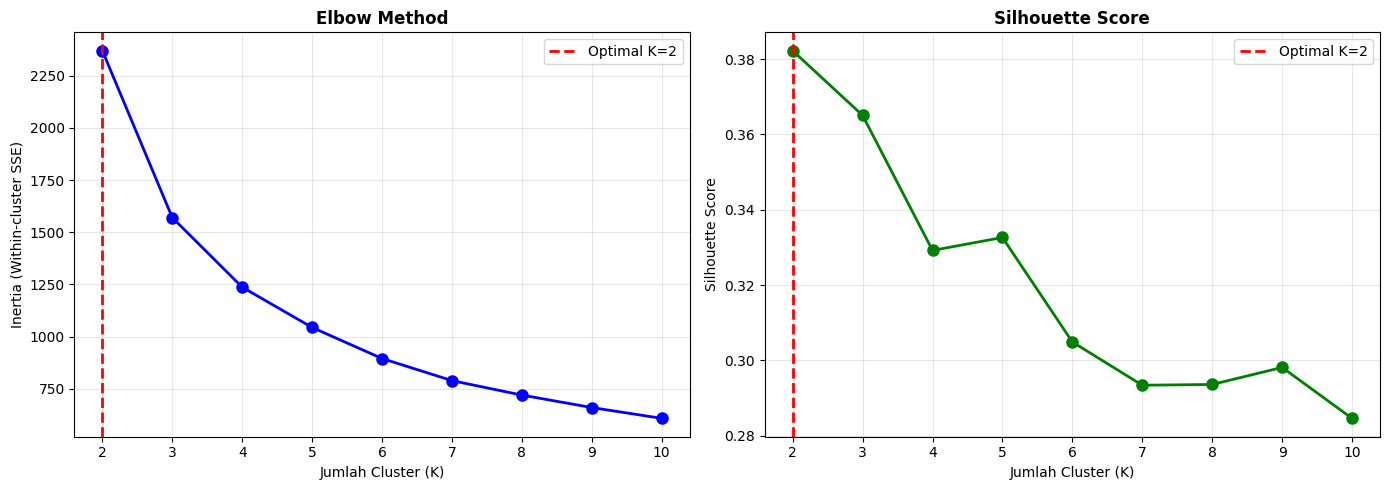

In [25]:
# 6.3 Visualisasi Elbow & Silhouette
print("\n[6.3] Visualisasi Elbow Method & Silhouette Score")
print("-"*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal K={optimal_k}')
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(list(K_range), silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal K={optimal_k}')
axes[1].set_title('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# 6.4 K-Means Clustering
print(f"\n[6.4] K-Means Clustering (K={optimal_k})")
print("-"*50)

kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster_KMeans'] = kmeans_model.fit_predict(X_cluster_scaled)

print("Distribusi Cluster:")
km_counts = rfm['Cluster_KMeans'].value_counts().sort_index()
for cluster, count in km_counts.items():
    print(f"  Cluster {cluster}: {count} customers ({count/len(rfm)*100:.1f}%)")

sil_kmeans = silhouette_score(X_cluster_scaled, rfm['Cluster_KMeans'])
print(f"\nSilhouette Score: {sil_kmeans:.4f}")


[6.4] K-Means Clustering (K=2)
--------------------------------------------------
Distribusi Cluster:
  Cluster 0: 809 customers (55.5%)
  Cluster 1: 648 customers (44.5%)

Silhouette Score: 0.3822


In [27]:
# 6.5 Hierarchical Clustering
print(f"\n[6.5] Hierarchical Clustering (K={optimal_k})")
print("-"*50)

hc_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
rfm['Cluster_HC'] = hc_model.fit_predict(X_cluster_scaled)

print("Distribusi Cluster:")
hc_counts = rfm['Cluster_HC'].value_counts().sort_index()
for cluster, count in hc_counts.items():
    print(f"  Cluster {cluster}: {count} customers ({count/len(rfm)*100:.1f}%)")

sil_hc = silhouette_score(X_cluster_scaled, rfm['Cluster_HC'])
print(f"\nSilhouette Score: {sil_hc:.4f}")


[6.5] Hierarchical Clustering (K=2)
--------------------------------------------------
Distribusi Cluster:
  Cluster 0: 897 customers (61.6%)
  Cluster 1: 560 customers (38.4%)

Silhouette Score: 0.3676


In [28]:
# 6.6 Perbandingan Clustering
print("\n[6.6] Perbandingan Metode Clustering")
print("-"*50)

print(f"K-Means Silhouette Score     : {sil_kmeans:.4f}")
print(f"Hierarchical Silhouette Score: {sil_hc:.4f}")

best_clustering = 'K-Means' if sil_kmeans >= sil_hc else 'Hierarchical'
print(f"\nMetode Terbaik: {best_clustering}")


[6.6] Perbandingan Metode Clustering
--------------------------------------------------
K-Means Silhouette Score     : 0.3822
Hierarchical Silhouette Score: 0.3676

Metode Terbaik: K-Means


In [29]:
# 6.7 Karakteristik Cluster
print("\n[6.7] Karakteristik Cluster (K-Means)")
print("-"*50)

cluster_summary = rfm.groupby('Cluster_KMeans')[cluster_features].agg(['mean', 'std']).round(2)
print(cluster_summary)


[6.7] Karakteristik Cluster (K-Means)
--------------------------------------------------
               Recency        Frequency       Monetary        
                  mean    std      mean   std     mean     std
Cluster_KMeans                                                
0               136.77  91.90      2.28  0.89   351.94  175.18
1                52.99  45.19      4.86  1.31   869.40  280.41



[6.8] Interpretasi Segmen Customer
--------------------------------------------------
  Cluster 0: At Risk / Need Attention
    - Recency: 136.8 hari, Frequency: 2.3x, Monetary: $351.94
  Cluster 1: Champions (Best Customers)
    - Recency: 53.0 hari, Frequency: 4.9x, Monetary: $869.40


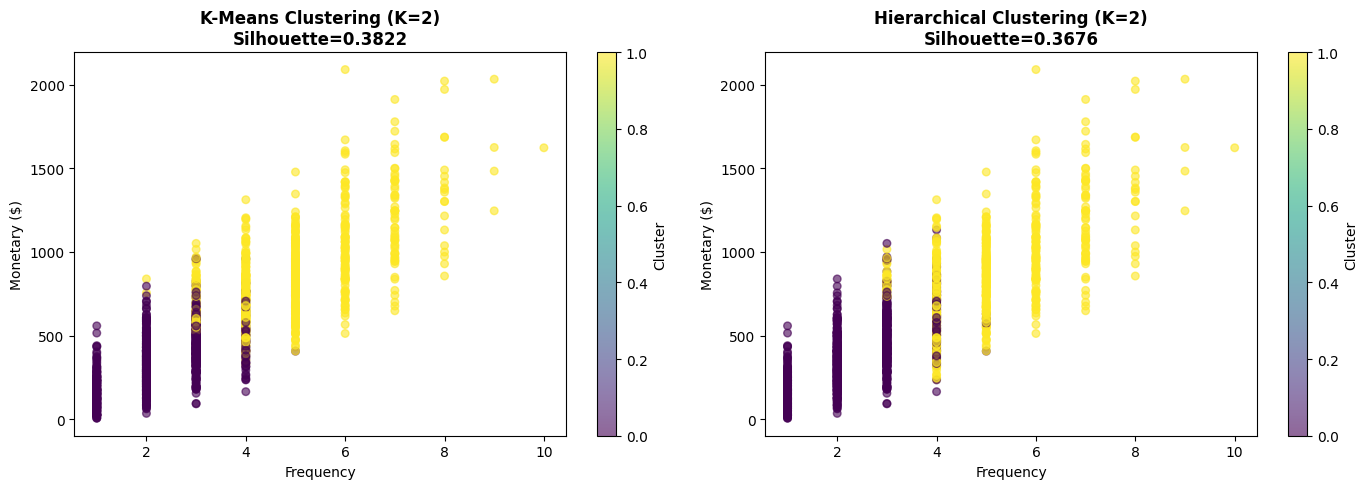

In [30]:
# 6.8 Interpretasi & Visualisasi Cluster
print("\n[6.8] Interpretasi Segmen Customer")
print("-"*50)

cluster_means = rfm.groupby('Cluster_KMeans')[cluster_features].mean()
for cluster in cluster_means.index:
    r = cluster_means.loc[cluster, 'Recency']
    f = cluster_means.loc[cluster, 'Frequency']
    m = cluster_means.loc[cluster, 'Monetary']
    
    # Tentukan label
    if r < cluster_means['Recency'].median() and f > cluster_means['Frequency'].median() and m > cluster_means['Monetary'].median():
        label = "Champions (Best Customers)"
    elif r < cluster_means['Recency'].median() and f > cluster_means['Frequency'].median():
        label = "Loyal Customers"
    elif r < cluster_means['Recency'].median() and m > cluster_means['Monetary'].median():
        label = "Potential Loyalists"
    elif r > cluster_means['Recency'].median() and f < cluster_means['Frequency'].median():
        label = "At Risk / Need Attention"
    else:
        label = "Regular Customers"
    
    print(f"  Cluster {cluster}: {label}")
    print(f"    - Recency: {r:.1f} hari, Frequency: {f:.1f}x, Monetary: ${m:.2f}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means
scatter1 = axes[0].scatter(rfm['Frequency'], rfm['Monetary'],
                           c=rfm['Cluster_KMeans'], cmap='viridis', alpha=0.6, s=30)
axes[0].set_title(f'K-Means Clustering (K={optimal_k})\nSilhouette={sil_kmeans:.4f}', fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary ($)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Hierarchical
scatter2 = axes[1].scatter(rfm['Frequency'], rfm['Monetary'],
                           c=rfm['Cluster_HC'], cmap='viridis', alpha=0.6, s=30)
axes[1].set_title(f'Hierarchical Clustering (K={optimal_k})\nSilhouette={sil_hc:.4f}', fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary ($)')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

---
## BAGIAN 7: ASSOCIATION RULE MINING

**Dataset**: Groceries Dataset (Transaksi dari URL Publik)  
**Algoritma**: Apriori  
**Analisis**: Market Basket Analysis

In [ ]:
# ============================================================================
# BAGIAN 7: ASSOCIATION RULE MINING
# ============================================================================
print("\n" + "="*70)
print("BAGIAN 7: ASSOCIATION RULE MINING")
print("="*70)

# 7.1 Encoding Transaksi (menggunakan data asli dari URL)
print("\n[7.1] Encoding Transaksi dari Groceries Dataset")
print("-"*50)

# Gunakan transaksi yang sudah difilter (>1 item)
transactions_for_rules = transactions_filtered

te = TransactionEncoder()
te_array = te.fit(transactions_for_rules).transform(transactions_for_rules)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

# Konversi nama kolom ke string
df_trans.columns = [str(col) for col in df_trans.columns]

print(f"Jumlah transaksi: {len(transactions_for_rules)}")
print(f"Jumlah produk unik: {len(te.columns_)}")
print(f"\n10 Produk pertama: {list(df_trans.columns)[:10]}")


BAGIAN 7: ASSOCIATION RULE MINING

[7.1] Encoding Transaksi
--------------------------------------------------
Jumlah transaksi: 4513
Jumlah produk unik: 20

Produk: ['ASSORTED COLOUR BIRD ORNAMENT', 'BOX OF 6 ASSORTED COLOUR TEASPOONS', 'BOX OF VINTAGE ALPHABET BLOCKS', 'BOX OF VINTAGE JIGSAW BLOCKS', 'CREAM CUPID HEARTS COAT HANGER', 'DOORMAT NEW ENGLAND', 'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'HAND WARMER RED POLKA DOT', 'HAND WARMER UNION JACK']...


In [32]:
# 7.2 Frequent Itemsets
print("\n[7.2] Frequent Itemsets (Apriori)")
print("-"*50)

frequent_itemsets = apriori(df_trans, min_support=0.02, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print(f"Jumlah frequent itemsets: {len(frequent_itemsets)}")
print(f"\nTop 15 Frequent Itemsets:")
print(f"{'Itemset':<50} {'Support':>10}")
print("-"*62)

top_items = frequent_itemsets.nlargest(15, 'support')
for _, row in top_items.iterrows():
    items_str = ', '.join([str(i)[:25] for i in row['itemsets']])
    if len(items_str) > 48:
        items_str = items_str[:45] + "..."
    print(f"{items_str:<50} {row['support']:>10.4f}")


[7.2] Frequent Itemsets (Apriori)
--------------------------------------------------
Jumlah frequent itemsets: 40

Top 15 Frequent Itemsets:
Itemset                                               Support
--------------------------------------------------------------
DOORMAT NEW ENGLAND                                    0.1416
RECIPE BOX WITH METAL HEA                              0.1416
SET 7 BABUSHKA NESTING BO                              0.1356
FELTCRAFT PRINCESS CHARLO                              0.1354
WHITE HANGING HEART T-LIG                              0.1345
POPPY FLOWER COAT HANGER                               0.1336
IVORY KNITTED MUG COSY                                 0.1334
CREAM CUPID HEARTS COAT H                              0.1292
BOX OF 6 ASSORTED COLOUR                               0.1274
WHITE METAL LANTERN                                    0.1274
GLASS STAR FROSTED T-LIGH                              0.1267
RECIPE BOX WITH METAL HEA, DOORMAT NEW ENGLAND     

In [33]:
# 7.3 Association Rules
print("\n[7.3] Association Rules")
print("-"*50)

# Konversi itemsets
frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].apply(
    lambda x: frozenset([str(item) for item in x])
)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0,
                          num_itemsets=len(frequent_itemsets))

if len(rules) > 0:
    rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join([str(i)[:20] for i in x]))
    rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join([str(i)[:20] for i in x]))
    
    print(f"Jumlah rules ditemukan: {len(rules)}")
    print(f"\nTop 15 Rules (berdasarkan Lift):")
    print(f"{'Antecedent':<25} {'Consequent':<25} {'Supp':>7} {'Conf':>7} {'Lift':>7}")
    print("-"*77)
    
    top_rules = rules.nlargest(15, 'lift')
    for _, row in top_rules.iterrows():
        ant = row['antecedents_str'][:23]
        cons = row['consequents_str'][:23]
        print(f"{ant:<25} {cons:<25} {row['support']:>7.4f} {row['confidence']:>7.4f} {row['lift']:>7.4f}")
else:
    print("Tidak ada rules yang memenuhi kriteria.")


[7.3] Association Rules
--------------------------------------------------
Jumlah rules ditemukan: 44

Top 15 Rules (berdasarkan Lift):
Antecedent                Consequent                   Supp    Conf    Lift
-----------------------------------------------------------------------------
IVORY KNITTED MUG CO      BOX OF 6 ASSORTED CO       0.1064  0.7973  6.2581
BOX OF 6 ASSORTED CO      IVORY KNITTED MUG CO       0.1064  0.8348  6.2581
POPPY FLOWER COAT HA      CREAM CUPID HEARTS C       0.1064  0.7960  6.1620
CREAM CUPID HEARTS C      POPPY FLOWER COAT HA       0.1064  0.8233  6.1620
SET 7 BABUSHKA NESTI      FELTCRAFT PRINCESS C       0.1103  0.8137  6.0104
FELTCRAFT PRINCESS C      SET 7 BABUSHKA NESTI       0.1103  0.8151  6.0104
RECIPE BOX WITH META      DOORMAT NEW ENGLAND        0.1177  0.8310  5.8689
DOORMAT NEW ENGLAND       RECIPE BOX WITH META       0.1177  0.8310  5.8689
WHITE METAL LANTERN, WH   GLASS STAR FROSTED T       0.0623  0.7318  5.7736
GLASS STAR FROSTED T     

In [34]:
# 7.4 Interpretasi Rules
print("\n[7.4] Interpretasi Association Rules")
print("-"*50)

if len(rules) > 0:
    best_rule = rules.loc[rules['lift'].idxmax()]
    
    print("Rule dengan Lift Tertinggi:")
    print(f"\n  IF customer membeli: [{best_rule['antecedents_str']}]")
    print(f"  THEN kemungkinan juga membeli: [{best_rule['consequents_str']}]")
    print(f"\n  Metrics:")
    print(f"    Support   : {best_rule['support']:.4f} ({best_rule['support']*100:.2f}% transaksi)")
    print(f"    Confidence: {best_rule['confidence']:.4f} ({best_rule['confidence']*100:.2f}%)")
    print(f"    Lift      : {best_rule['lift']:.4f}")
    
    print(f"\n  Interpretasi:")
    print(f"    Lift > 1 menunjukkan adanya asosiasi positif antara produk.")
    print(f"    Customer yang membeli {best_rule['antecedents_str'][:30]} memiliki")
    print(f"    kemungkinan {best_rule['lift']:.2f}x lebih tinggi untuk juga membeli produk lainnya.")


[7.4] Interpretasi Association Rules
--------------------------------------------------
Rule dengan Lift Tertinggi:

  IF customer membeli: [IVORY KNITTED MUG CO]
  THEN kemungkinan juga membeli: [BOX OF 6 ASSORTED CO]

  Metrics:
    Support   : 0.1064 (10.64% transaksi)
    Confidence: 0.7973 (79.73%)
    Lift      : 6.2581

  Interpretasi:
    Lift > 1 menunjukkan adanya asosiasi positif antara produk.
    Customer yang membeli IVORY KNITTED MUG CO memiliki
    kemungkinan 6.26x lebih tinggi untuk juga membeli produk lainnya.



[7.5] Visualisasi Association Rules
--------------------------------------------------


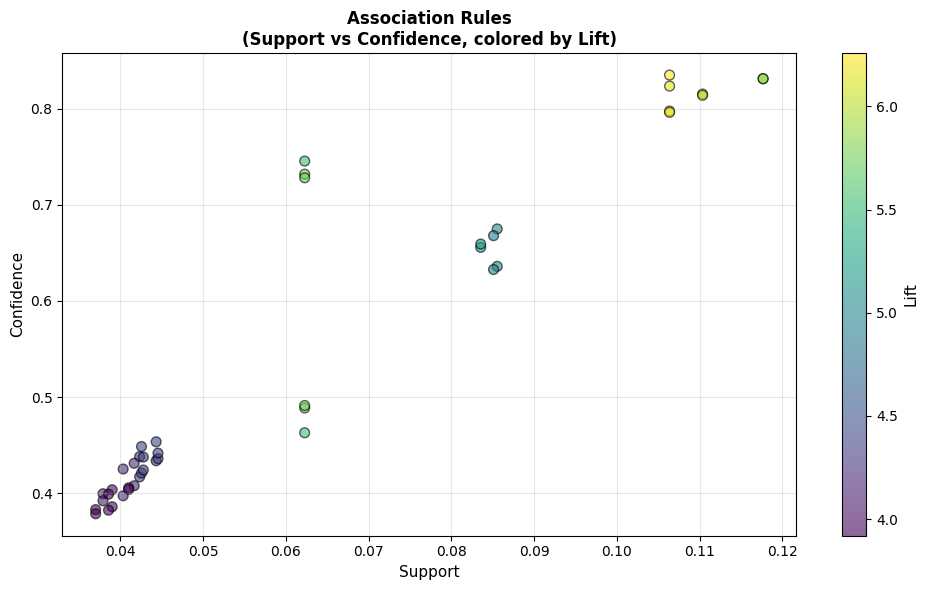

In [35]:
# 7.5 Visualisasi Association Rules
print("\n[7.5] Visualisasi Association Rules")
print("-"*50)

if len(rules) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    scatter = ax.scatter(rules['support'], rules['confidence'],
                        c=rules['lift'], cmap='viridis', alpha=0.6, s=50, edgecolor='black')
    
    ax.set_xlabel('Support', fontsize=11)
    ax.set_ylabel('Confidence', fontsize=11)
    ax.set_title('Association Rules\n(Support vs Confidence, colored by Lift)', fontsize=12, fontweight='bold')
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Lift', fontsize=11)
    
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada rules untuk divisualisasikan.")

---
## BAGIAN 8: KESIMPULAN DAN REKOMENDASI

In [ ]:
# ============================================================================
# BAGIAN 8: KESIMPULAN DAN REKOMENDASI
# ============================================================================
print("\n" + "="*70)
print("BAGIAN 8: KESIMPULAN DAN REKOMENDASI")
print("="*70)

print("\n" + "="*70)
print("RINGKASAN HASIL ANALISIS")
print("="*70)

print("\n[1] KLASIFIKASI - High Value Customer Prediction")
print("-"*50)
print(f"    Dataset      : Groceries (Public Dataset)")
print(f"    Jumlah Data  : {len(rfm)} customers")
print(f"    Model Terbaik: {best_model}")
print(f"    Akurasi      : {hasil_klasifikasi[best_model]*100:.2f}%")
print(f"    Top Feature  : {feature_imp.iloc[0]['Feature']}")

print("\n[2] CLUSTERING - Customer Segmentation (RFM)")
print("-"*50)
print(f"    Dataset       : Groceries (Public Dataset)")
print(f"    Jumlah Cluster: {optimal_k}")
print(f"    Metode Terbaik: {best_clustering}")
print(f"    Silhouette    : {max(sil_kmeans, sil_hc):.4f}")

print("\n[3] ASSOCIATION RULE MINING - Market Basket Analysis")
print("-"*50)
print(f"    Dataset          : Groceries (Public Dataset)")
print(f"    Jumlah Transaksi : {len(transactions_for_rules)}")
print(f"    Frequent Itemsets: {len(frequent_itemsets)}")
print(f"    Association Rules: {len(rules)}")


BAGIAN 8: KESIMPULAN DAN REKOMENDASI

RINGKASAN HASIL ANALISIS

[1] KLASIFIKASI - High Value Customer Prediction
--------------------------------------------------
    Dataset      : Online Retail
    Jumlah Data  : 1457 customers
    Model Terbaik: Random Forest
    Akurasi      : 100.00%
    Top Feature  : Frequency

[2] CLUSTERING - Customer Segmentation (RFM)
--------------------------------------------------
    Dataset       : Online Retail
    Jumlah Cluster: 2
    Metode Terbaik: K-Means
    Silhouette    : 0.3822

[3] ASSOCIATION RULE MINING - Market Basket Analysis
--------------------------------------------------
    Dataset          : Online Retail
    Jumlah Transaksi : 4513
    Frequent Itemsets: 40
    Association Rules: 44


In [ ]:
print("\n" + "="*70)
print("REKOMENDASI BISNIS")
print("="*70)

print("""
1. HIGH VALUE CUSTOMER RETENTION (Berdasarkan Klasifikasi)
   - Identifikasi customer dengan potensi high-value menggunakan model
   - Berikan program VIP untuk customer high-value
   - Personalisasi penawaran berdasarkan pola pembelian
   - Monitor customer dengan Monetary dan Frequency tinggi

2. CUSTOMER SEGMENTATION STRATEGY (Berdasarkan Clustering RFM)
   - Champions: Berikan reward dan program referral
   - Loyal Customers: Upselling dan cross-selling
   - Potential Loyalists: Tingkatkan engagement
   - At Risk: Kampanye win-back dan diskon khusus

3. PRODUCT BUNDLING (Berdasarkan Association Rules)
   - Buat bundle produk berdasarkan pola pembelian
   - Implementasi recommendation system di website
   - Optimasi product placement
   - Cross-selling berdasarkan rules dengan lift tinggi
""")

print("="*70)
print("PROGRAM FINAL PROJECT SELESAI")
print("="*70)
print("\nDataset: Groceries (Public Dataset dari URL)")
print("Sumber : https://github.com/stedy/Machine-Learning-with-R-datasets")
print("Metode : Klasifikasi, Clustering, Association Rule Mining")
print("="*70)


REKOMENDASI BISNIS

1. HIGH VALUE CUSTOMER RETENTION (Berdasarkan Klasifikasi)
   - Identifikasi customer dengan potensi high-value menggunakan model
   - Berikan program VIP untuk customer high-value
   - Personalisasi penawaran berdasarkan pola pembelian
   - Monitor customer dengan Monetary dan Frequency tinggi

2. CUSTOMER SEGMENTATION STRATEGY (Berdasarkan Clustering RFM)
   - Champions: Berikan reward dan program referral
   - Loyal Customers: Upselling dan cross-selling
   - Potential Loyalists: Tingkatkan engagement
   - At Risk: Kampanye win-back dan diskon khusus

3. PRODUCT BUNDLING (Berdasarkan Association Rules)
   - Buat bundle produk berdasarkan pola pembelian
   - Implementasi recommendation system di website
   - Optimasi product placement
   - Cross-selling berdasarkan rules dengan lift tinggi

PROGRAM FINAL PROJECT SELESAI

Dataset: Online Retail (1 Dataset untuk semua metode)
Metode : Klasifikasi, Clustering, Association Rule Mining
